In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
plt.style.use("ggplot")

In [3]:
df = pd.read_csv("delhiaqi.csv")
df.head()

,date,co,no,no2,o3,so2,pm2_5,pm10,nh3
0,2023-01-01 00:00:00,1655.58,1.66,39.41,5.90,17.88,169.29,194.64,5.83
1,2023-01-01 01:00:00,1869.20,6.82,42.16,1.99,22.17,182.84,211.08,7.66
2,2023-01-01 02:00:00,2510.07,27.72,43.87,0.02,30.04,220.25,260.68,11.40
3,2023-01-01 03:00:00,3150.94,55.43,44.55,0.85,35.76,252.90,304.12,13.55
4,2023-01-01 04:00:00,3471.37,68.84,45.24,5.45,39.10,266.36,322.80,14.19


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 561 entries, 0 to 560
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    561 non-null    str    
 1   co      561 non-null    float64
 2   no      561 non-null    float64
 3   no2     561 non-null    float64
 4   o3      561 non-null    float64
 5   so2     561 non-null    float64
 6   pm2_5   561 non-null    float64
 7   pm10    561 non-null    float64
 8   nh3     561 non-null    float64
dtypes: float64(8), str(1)
memory usage: 39.6 KB


In [5]:
df.describe()

,co,no,no2,o3,so2,pm2_5,pm10,nh3
count,561.000000,561.000000,561.000000,561.000000,561.000000,561.000000,561.000000,561.000000
mean,3814.942210,51.181979,75.292496,30.141943,64.655936,358.256364,420.988414,26.425062
std,3227.744681,83.904476,42.473791,39.979405,61.073080,227.359117,271.287026,36.563094
min,654.220000,0.000000,13.370000,0.000000,5.250000,60.100000,69.080000,0.630000
25%,1708.980000,3.380000,44.550000,0.070000,28.130000,204.450000,240.900000,8.230000
50%,2590.180000,13.300000,63.750000,11.800000,47.210000,301.170000,340.900000,14.820000
75%,4432.680000,59.010000,97.330000,47.210000,77.250000,416.650000,482.570000,26.350000
max,16876.220000,425.580000,263.210000,164.510000,511.170000,1310.200000,1499.270000,267.510000


In [6]:
df.isnull().sum()

date     0
co       0
no       0
no2      0
o3       0
so2      0
pm2_5    0
pm10     0
nh3      0
dtype: int64

In [7]:
df["date"] = pd.to_datetime(df["date"])

df.head()

,date,co,no,no2,o3,so2,pm2_5,pm10,nh3
0,2023-01-01 00:00:00,1655.58,1.66,39.41,5.90,17.88,169.29,194.64,5.83
1,2023-01-01 01:00:00,1869.20,6.82,42.16,1.99,22.17,182.84,211.08,7.66
2,2023-01-01 02:00:00,2510.07,27.72,43.87,0.02,30.04,220.25,260.68,11.40
3,2023-01-01 03:00:00,3150.94,55.43,44.55,0.85,35.76,252.90,304.12,13.55
4,2023-01-01 04:00:00,3471.37,68.84,45.24,5.45,39.10,266.36,322.80,14.19


# Research Questions

1. How does PM2.5 vary over time?

2. What is the distribution of PM2.5 values?

3. Is there a relationship between PM2.5 and PM10?

4. Which pollutants have the highest average concentration?

5. How are pollutants correlated?

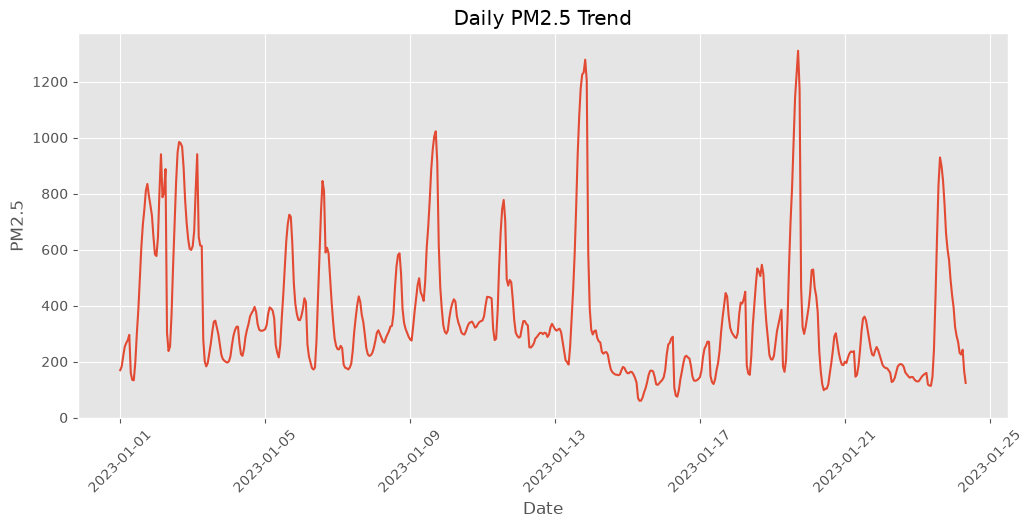

In [8]:
plt.figure(figsize=(12,5))

plt.plot(df["date"],df["pm2_5"])

plt.title("Daily PM2.5 Trend")

plt.xlabel("Date")

plt.ylabel("PM2.5")

plt.xticks(rotation=45)

plt.show()

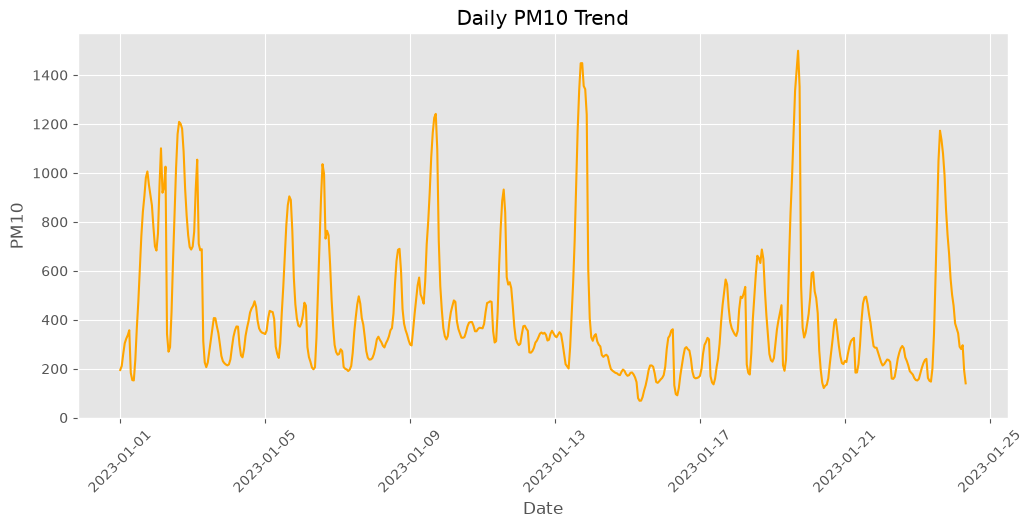

In [9]:
plt.figure(figsize=(12,5))

plt.plot(df["date"],df["pm10"],color="orange")

plt.title("Daily PM10 Trend")

plt.xlabel("Date")

plt.ylabel("PM10")

plt.xticks(rotation=45)

plt.show()

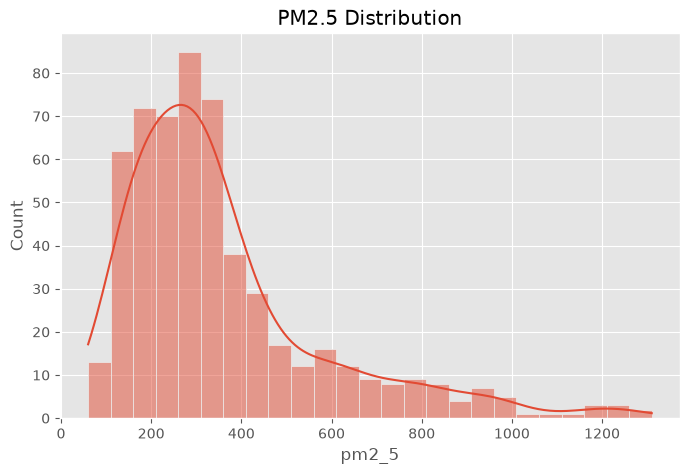

In [10]:
plt.figure(figsize=(8,5))

sns.histplot(df["pm2_5"],bins=25,kde=True)

plt.title("PM2.5 Distribution")

plt.show()

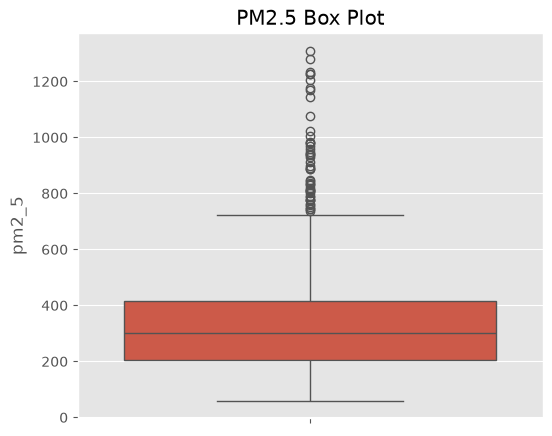

In [11]:
plt.figure(figsize=(6,5))

sns.boxplot(y=df["pm2_5"])

plt.title("PM2.5 Box Plot")

plt.show()

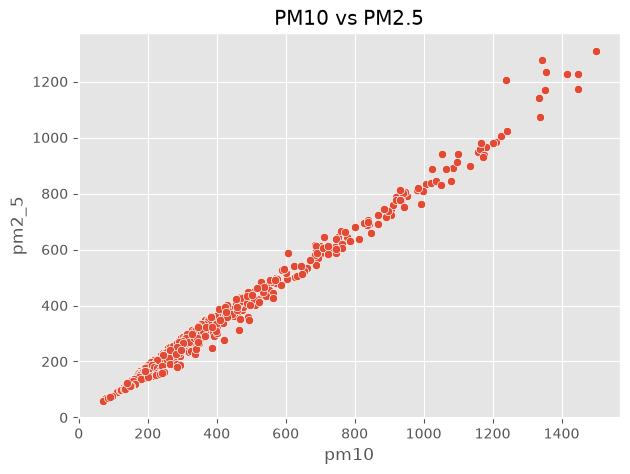

In [12]:
plt.figure(figsize=(7,5))

sns.scatterplot(data=df,
                x="pm10",
                y="pm2_5")

plt.title("PM10 vs PM2.5")

plt.show()

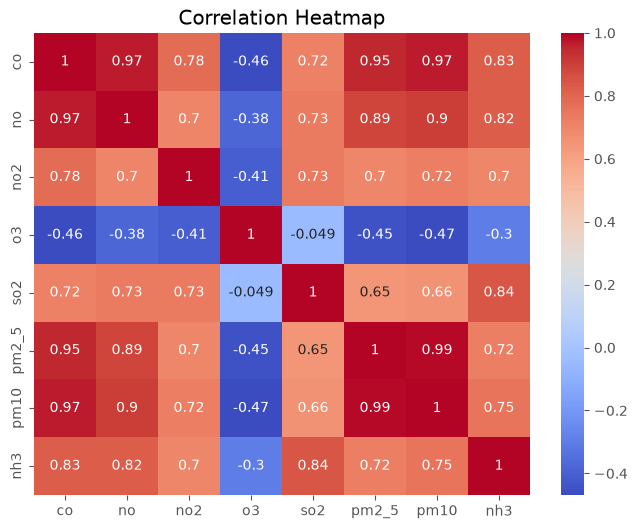

In [13]:
plt.figure(figsize=(8,6))

sns.heatmap(df.drop(columns=["date"]).corr(),
            annot=True,
            cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

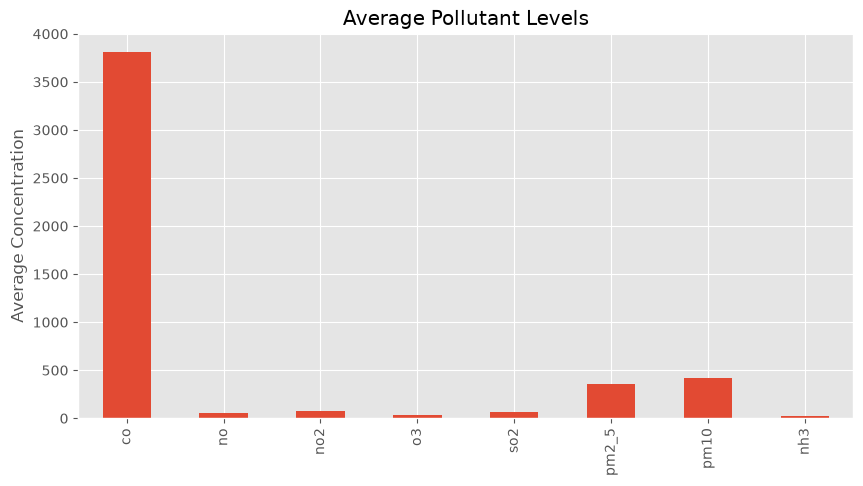

In [14]:
pollutants=["co","no","no2","o3","so2","pm2_5","pm10","nh3"]

plt.figure(figsize=(10,5))

df[pollutants].mean().plot(kind="bar")

plt.title("Average Pollutant Levels")

plt.ylabel("Average Concentration")

plt.show()

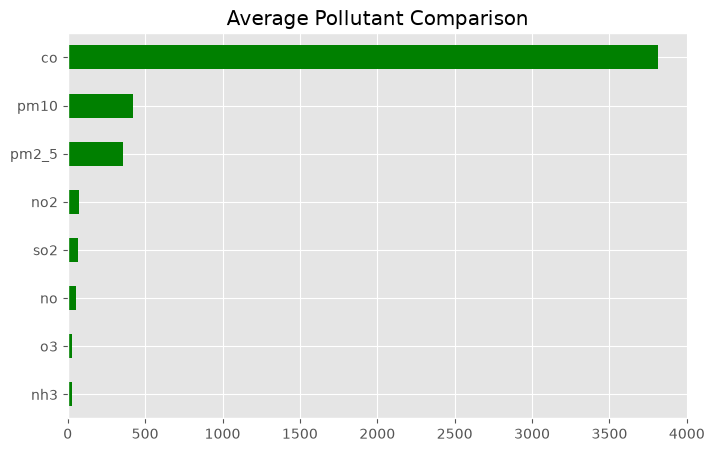

In [15]:
df[pollutants].mean().sort_values().plot(
    kind="barh",
    figsize=(8,5),
    color="green"
)

plt.title("Average Pollutant Comparison")

plt.show()

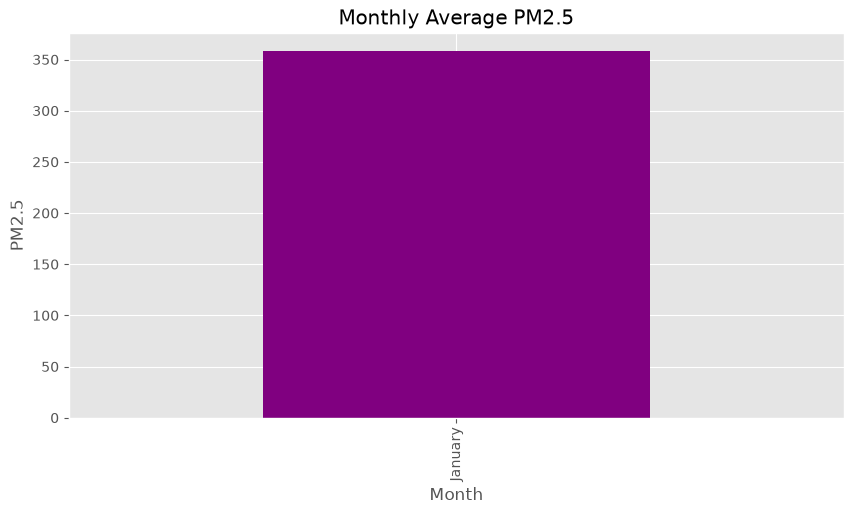

In [16]:
df["Month"]=df["date"].dt.month_name()

monthly=df.groupby("Month")["pm2_5"].mean()

monthly.plot(kind="bar",
             figsize=(10,5),
             color="purple")

plt.title("Monthly Average PM2.5")

plt.ylabel("PM2.5")

plt.show()

In [17]:
print("Mean PM2.5 :",df["pm2_5"].mean())

print("Median PM2.5 :",df["pm2_5"].median())

print("Maximum PM2.5 :",df["pm2_5"].max())

print("Minimum PM2.5 :",df["pm2_5"].min())

print("Standard Deviation :",df["pm2_5"].std())

Mean PM2.5 : 358.25636363636363
Median PM2.5 : 301.17
Maximum PM2.5 : 1310.2
Minimum PM2.5 : 60.1
Standard Deviation : 227.3591169877899


In [18]:
fig=px.line(df,
            x="date",
            y="pm2_5",
            title="Interactive PM2.5 Trend")

fig.show()

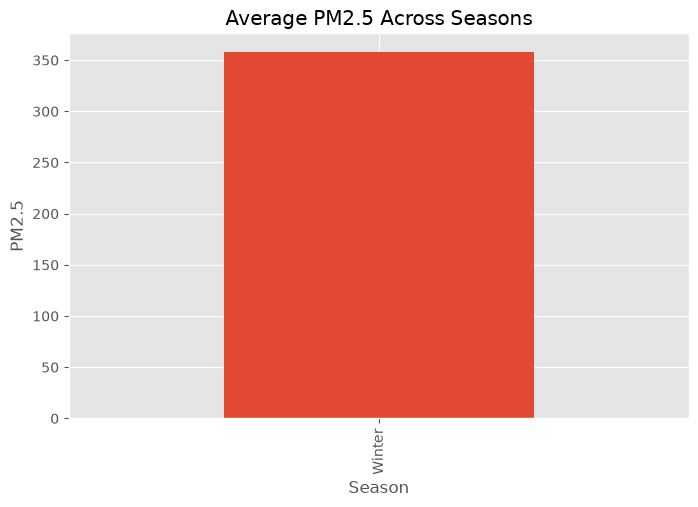

In [23]:
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Summer"
    elif month in [6, 7, 8, 9]:
        return "Monsoon"
    else:
        return "Post-Monsoon"

df["Season"] = df["date"].dt.month.apply(get_season)

seasonal_pm25 = df.groupby("Season")["pm2_5"].mean()

seasonal_pm25
import matplotlib.pyplot as plt

seasonal_pm25.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Average PM2.5 Across Seasons")

plt.ylabel("PM2.5")

plt.show()

In [20]:
print(df.columns)

Index(['date', 'co', 'no', 'no2', 'o3', 'so2', 'pm2_5', 'pm10', 'nh3',
       'Month'],
      dtype='str')


### Observation

Winter records the highest PM2.5 concentration because pollutants remain trapped due to low temperatures and reduced wind speed.

Monsoon has the lowest PM2.5 concentration because rainfall washes away suspended particles.

# Impact of Geographical Factors

Delhi's geographical location significantly influences air quality.

Important geographical factors include:

• Delhi is landlocked, reducing natural pollutant dispersion.

• The Himalayas act as a barrier, preventing pollutants from moving northward.

• During winter, weak wind speeds reduce pollutant dispersion.

• Dust transported from Rajasthan increases particulate matter.

• Crop burning in Punjab and Haryana contributes substantially to PM2.5 levels during post-monsoon months.

These geographical characteristics make Delhi especially vulnerable to severe air pollution episodes.

# Strategies for Air Quality Improvement

Based on the analysis, the following measures are recommended:

• Promote electric vehicles and public transportation.

• Strengthen industrial emission regulations.

• Control construction dust through better site management.

• Encourage scientific crop residue management to reduce stubble burning.

• Expand urban green spaces.

• Install additional real-time air quality monitoring stations.

• Increase public awareness regarding pollution control measures.

These strategies can help reduce pollutant concentrations and improve public health in Delhi.

# Conclusion

The analysis shows that PM2.5 and PM10 are the major pollutants affecting air quality in Delhi. The visualizations reveal fluctuations in pollutant concentrations over time, while the heatmap highlights correlations among pollutants. These findings can help understand pollution patterns and support environmental planning and public health initiatives.

# Environmental Challenges in Delhi
Delhi experiences severe air pollution due to multiple environmental and human-induced factors.

Major challenges include:

• Vehicular emissions from millions of vehicles.

• Industrial emissions from factories and power plants.

• Dust from construction activities.

• Crop residue burning in neighboring states during October and November.

• Firecracker emissions during festivals.

• Winter temperature inversion, which traps pollutants near the surface.

These factors contribute to consistently high AQI levels, particularly during winter months, affecting public health and visibility.

# Future Scope

Future work may include:

• Machine Learning models for AQI prediction

• Weather-based pollution forecasting

• Real-time AQI dashboard

• Integration with IoT air quality sensors

• Predictive analytics for public health alerts